# KNN Regression Activity (Baseline dataset)

In [7]:
import pandas as pd
df = pd.read_csv("../datasets/exam_score_baseline.csv")

## I - Define the Modeling Problem

**Target variable (y):**
- Exam score (`Exam_Score`)

**Predictors (X):**
- Number of hours studied (`Hours_Studied`)
- Percentage of class attendance (`Attendance_Percent`)
- Number of hours slept before exam (`Hours_Slept`)
- Number of assignments completed (`Assignments_Completed`)

Each record's unique ID (`Synthetic_Record_ID`) is excluded because it is only an identifier.

In [8]:
numeric_features = [
    "Hours_Studied",
    "Attendance_Percent",
    "Sleep_Hours",
    "Assignments_Completed"
]

X = df[numeric_features]
y = df["Exam_Score"]

## II - Inspect Data Quality

This step checks the quality of the dataset before building the model. We are checking the dataset size, missing values, duplicate IDs, summary statistics, unusual observations, and relationships between variables.

### Records and Fields

Each **row** of the dataset is one observation (a student) and each **column** is one variable

In [9]:
# Count records and fields
print(f"Number of records (rows):   {df.shape[0]}")
print(f"Number of fields (columns): {df.shape[1]}")
print()
print("Column data types:")
print(df.dtypes)

Number of records (rows):   80
Number of fields (columns): 6

Column data types:
Synthetic_Record_ID       object
Hours_Studied            float64
Attendance_Percent         int64
Sleep_Hours              float64
Assignments_Completed      int64
Exam_Score                 int64
dtype: object


### Missing Values

A missing value is a blank cell. We must verify that there are none in the dataset before modeling

In [10]:
# Detect missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing.to_string())
print(f"\nTotal missing cells: {missing.sum()}\n")

if (missing.sum() > 0): print("Missing values detected, data must be manually reviewed")
else: print ("No missing values detected, safe to proceed")

Missing values per column:
Synthetic_Record_ID      0
Hours_Studied            0
Attendance_Percent       0
Sleep_Hours              0
Assignments_Completed    0
Exam_Score               0

Total missing cells: 0

No missing values detected, safe to proceed


### Duplicate Identifiers

If the same student appears twice under the same `Synthetic_Record_ID`, the model counts their data twice. We must remove any duplicates before modeling

In [27]:
# Detect duplicate records
num_dupes = df['Synthetic_Record_ID'].duplicated().sum()
print(f"Duplicate Synthetic_Record_IDs: {num_dupes}\n")

if (num_dupes): print("Duplicate indentifiers detected, manual review required")
else: print("No duplicated identifiers detected, safe to proceed")

Duplicate Synthetic_Record_IDs: 0

No duplicated identifiers detected, safe to proceed


### Summary Statistics

Summary statistics compress each column into descriptive values that describe their shape

In [12]:
pd.set_option('display.precision', 2) # 2 decimal places
df.describe()

,Hours_Studied,Attendance_Percent,Sleep_Hours,Assignments_Completed,Exam_Score
count,80.00,80.00,80.00,80.00,80.00
mean,10.57,83.67,6.69,8.18,69.88
std,3.99,9.83,1.01,2.05,7.98
min,2.00,58.00,4.50,3.00,52.00
25%,7.85,76.00,6.00,7.00,65.00
50%,10.75,84.00,6.60,8.00,71.00
75%,13.15,91.00,7.33,10.00,75.00
max,20.00,100.00,9.20,12.00,87.00


### Plausible Value Ranges

Even with no missing values, a column can contain impossible values. For example, `Attendance_Percent` must be less than `100` and `Sleep_Hours` must be greater than `0`

In [13]:
# Define plausible value ranges
bounds = {
    'Hours_Studied':          (0, 24), # 0 - 24 hours studied
    'Attendance_Percent':     (0, 100), # 0 - 100 percent attendance
    'Sleep_Hours':            (0, 24), # 0 - 24 hours of sleep
    'Assignments_Completed':  (0, None), # 0 - infinity assignments completed
    'Exam_Score':             (0, 100), # 0 - 100 exam score
}

print("Plausible range check:")
all_clean = True
for col, (lo, hi) in bounds.items():
    mask = pd.Series(False, index=df.index)
    if lo is not None:
        mask |= (df[col] < lo)
    if hi is not None:
        mask |= (df[col] > hi)
    flagged = df.loc[mask, ['Synthetic_Record_ID', col]]
    if flagged.empty:
        print(f"  {col}: OK")
    else:
        print(f"  {col}: {len(flagged)} out-of-range value(s)")
        print(flagged.to_string(index=False))
        all_clean = False

if all_clean: print("\nAll values within plausible bounds, safe to proceed")
else: print("\nValues detected outside of their plausible bounds, manual review required")

Plausible range check:
  Hours_Studied: OK
  Attendance_Percent: OK
  Sleep_Hours: OK
  Assignments_Completed: OK
  Exam_Score: OK

All values within plausible bounds, safe to proceed


### Variable Correlation

Correlation shows the strength and direction of the linear relationship between two numerical variables

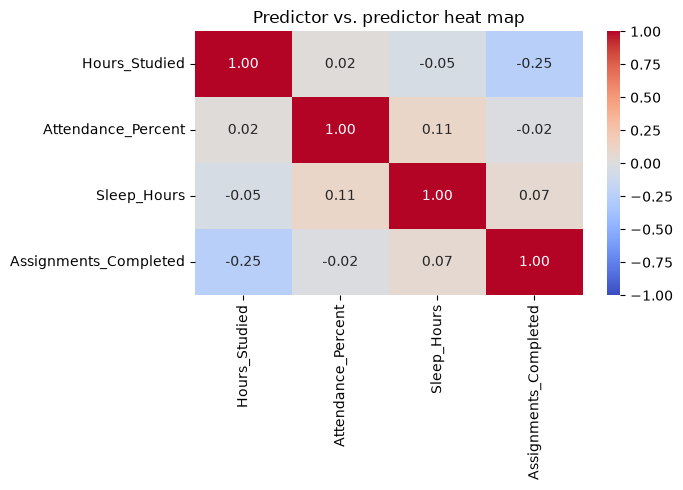

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = ['Hours_Studied', 'Attendance_Percent', 'Sleep_Hours',
                'Assignments_Completed']

# Predictor vs. predictor correlation heatmat
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, ax=ax)
ax.set_title('Predictor vs. predictor heat map')
plt.tight_layout()
plt.show()

In the above heatmap, correlation is represented by a value ranging from `-1` to `1`

- **Closer to `+1`:** *Strong positive relationship* - as one variable increases, the other increases
- **Closer to `-1`:** *Strong negative relationship* - as one variable increases, the other decreases
- **Closer to `0`:** *Weak linear relationship* - little to no correlation between the two variables

Highly correlated predictors are those that tend to move closely together. Within KNN, this can cause *"double weighting,"* where neighbors are pulled in a direction twice as much as they should be due to two predictors essentially measuring the same thing. Highly correlated predictors do not pose as much of an issue in KNN as they do in linear regression, but they are still worth checking for.

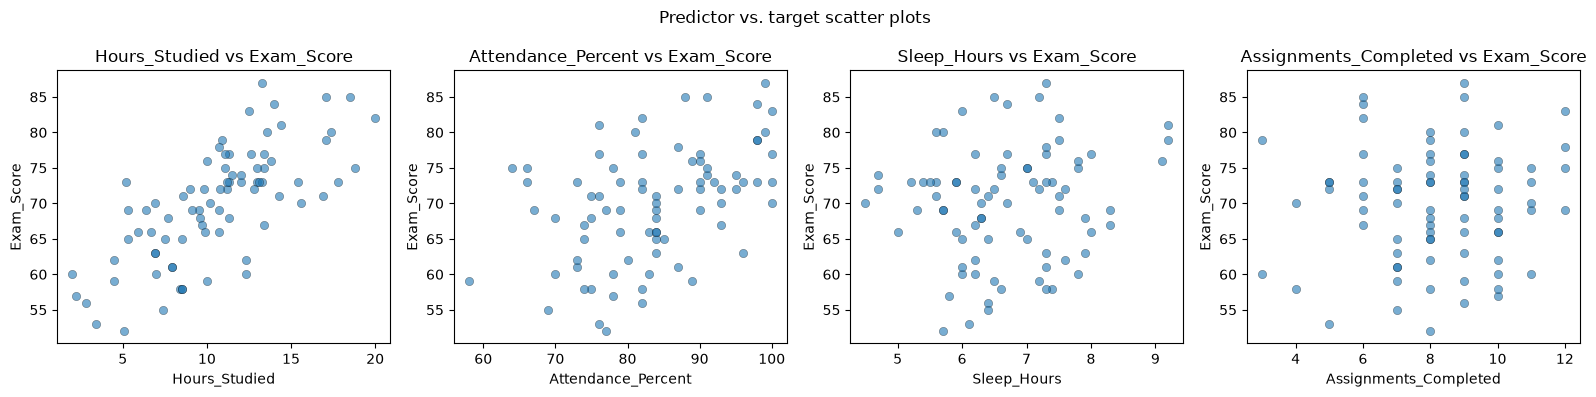

In [15]:
# Predictors vs. target scatter plots
predictors = ['Hours_Studied', 'Attendance_Percent', 'Sleep_Hours', 'Assignments_Completed']

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, predictors):
    ax.scatter(df[col], df['Exam_Score'], alpha=0.6, edgecolors='k', linewidths=0.3)
    ax.set_xlabel(col)
    ax.set_ylabel('Exam_Score')
    ax.set_title(f'{col} vs Exam_Score')

plt.suptitle('Predictor vs. target scatter plots')
plt.tight_layout()
plt.show()

In the above scatter plots, a positive correlation between a predictor and the target is represented by a consistent upward trend; a negative correlation is represented by a consistent downward trend.

In KNN regression, relationships between predictors and the target are not directly modeled like they are in linear regression. However, a predictor that has little to no correlation with the target can still add noise to the distance calculation, making neighbors "closer" for the wrong reason.

### Outlier Detection

An outlier is a value that sits far from the rest of the data

In [16]:
# Detect outlier values
outlier_rows = []

for col in numeric_features + ["Exam_Score"]:
    Q1 = df[col].quantile(0.25) # 25th percentile (75% scored above)
    Q3 = df[col].quantile(0.75) # 75th percentile (25% scored above)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_rows.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': round(IQR, 3),
        'Lower fence': round(lower, 3),
        'Upper fence': round(upper, 3),
        'Outliers flagged': n_out
    })

outlier_df = pd.DataFrame(outlier_rows).set_index('Column')
outlier_df

,Q1,Q3,IQR,Lower fence,Upper fence,Outliers flagged
Column,,,,,,
Hours_Studied,7.85,13.15,5.30,-0.10,21.10,0
Attendance_Percent,76.00,91.00,15.00,53.50,113.50,0
Sleep_Hours,6.00,7.33,1.32,4.01,9.31,0
Assignments_Completed,7.00,10.00,3.00,2.50,14.50,0
Exam_Score,65.00,75.00,10.00,50.00,90.00,0


The IQR method defines the fences as:

- **Lower fence:** Q1 − 1.5 × IQR
- **Upper fence:** Q3 + 1.5 × IQR

Any value outside these bounds is a potential outlier

If an outlier is used in the "training" of a model in KNN regression, it has the potential to be the nearest neighbor of a query point and cause the model's prediction to be innacurate. If an outlier is used as a query point or to test the model, its nearest neighbors may be very far away and skew the model's prediction.

### Data Quality Analysis

- The dataset contains **80** records and **6** fields
    - **5** predictors and **1** target
- No missing values or duplicate identifiers were found
- The numerical variables fall within reasonable ranges with no obvious abnormalities
- No two predictors had a strong correlation with one another
- `Hours_Studied` had the strongest positive correlation with `Exam_Score` while `Assignments_Completed` had the weakest
- No outlier values were detected across all predictors

## III - Predict the Effect of Scale

kNN finds nearest neighbors by calculating the distance between data points across all predictors.

Some predictors have larger ranges than others. For example, `Attendance_Percent` is expressed as a value from 0–100, whereas `Sleep_Hours` is much more narrow at 0-24; even a meaningful difference in sleep contributes very little to the total distance compared to attendance.

Calculating the range of each predictor based on the dataset gives us an idea as to which predictors might dominate the model.

In [17]:
for feature in numeric_features:
    feature_range = df[feature].max() - df[feature].min()
    print(f"{feature} range: {feature_range:.2f}")

Hours_Studied range: 18.00
Attendance_Percent range: 42.00
Sleep_Hours range: 4.70
Assignments_Completed range: 9.00


`Attendance_Percent` has the greatest raw range (42.00). `Sleep_Hours` has the least (4.70). In an unscaled model, `Attendance_Percent` would dominate the distance calculation and `Sleep_Hours` would contribute very little. This is not because they are more or less important, but because of the units they are measured in. Standardizing corrects for this before fitting the model.

## IV - Prepare the Predictors

All four predictors in the Group 1 baseline dataset are numerical, so no categorical encoding is needed.

The predictors will stay in their original form for now. Scaling will be done later inside the kNN pipeline so that the scaler only uses the training data.

## V - Compare Linear Regression and kNN

This task compares three models:

1. Ordinary Linear Regression
2. kNN with `k=5` using the original predictor values
3. kNN with `k=5` using standardized predictor values

The goal is to see whether scaling improves kNN performance and how kNN compares with the Linear Regression baseline

### Build the Models

The unscaled kNN model uses the original predictor values.

The scaled kNN model uses a pipeline that standardizes the predictors first and then applies kNN.

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

In [19]:
# Ordinary linear regression
linear_model = LinearRegression()

# Unscaled kNN regression
knn_unscaled = KNeighborsRegressor(
    n_neighbors=5
)

# Standardized kNN regression
knn_scaled = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=5))
])

### Cross-Validation Setup

All three models are evaluated using the same repeated cross-validation procedure:
- 5 folds
- 5 repeats
- `random_state = 407`

In [20]:
from sklearn.model_selection import RepeatedKFold, cross_validate

cv = RepeatedKFold(
    n_splits=5, # Divide data into 5 folds
    n_repeats=5, # Repeat folding 5 times
    random_state=407 # Constant random state ensures consisent folding
)

In [21]:
scoring = {
    "MAE": "neg_mean_absolute_error",
    "RMSE": "neg_root_mean_squared_error",
    "R2": "r2"
}

In [22]:
results_linear = cross_validate(
    linear_model,
    X,
    y,
    cv=cv,
    scoring=scoring
)

results_knn_unscaled = cross_validate(
    knn_unscaled,
    X,
    y,
    cv=cv,
    scoring=scoring
)

results_knn_scaled = cross_validate(
    knn_scaled,
    X,
    y,
    cv=cv,
    scoring=scoring
)

### Evaluate the Models

Each model is tested using MAE, RMSE, and R².

- **MAE:** Average prediction error. *Lower is better.*
- **RMSE:** Similar to **MAE,** but larger mistakes count more. *Lower is better.*
- **R²:** Shows how well the trends in the data are captured by the model. *Higher is better.*

In [23]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "kNN k=5 Unscaled",
        "kNN k=5 Scaled"
    ],
    "MAE Mean": [
        -results_linear["test_MAE"].mean(),
        -results_knn_unscaled["test_MAE"].mean(),
        -results_knn_scaled["test_MAE"].mean()
    ],
    "MAE SD": [
        results_linear["test_MAE"].std(),
        results_knn_unscaled["test_MAE"].std(),
        results_knn_scaled["test_MAE"].std()
    ],
    "RMSE Mean": [
        -results_linear["test_RMSE"].mean(),
        -results_knn_unscaled["test_RMSE"].mean(),
        -results_knn_scaled["test_RMSE"].mean()
    ],
    "RMSE SD": [
        results_linear["test_RMSE"].std(),
        results_knn_unscaled["test_RMSE"].std(),
        results_knn_scaled["test_RMSE"].std()
    ],
    "R2 Mean": [
        results_linear["test_R2"].mean(),
        results_knn_unscaled["test_R2"].mean(),
        results_knn_scaled["test_R2"].mean()
    ],
    "R2 SD": [
        results_linear["test_R2"].std(),
        results_knn_unscaled["test_R2"].std(),
        results_knn_scaled["test_R2"].std()
    ]
})

comparison.round(3)

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,Linear Regression,3.08,0.46,3.77,0.51,0.75,0.07
1,kNN k=5 Unscaled,4.27,0.51,5.13,0.54,0.55,0.09
2,kNN k=5 Scaled,4.39,0.49,5.28,0.51,0.52,0.12


### Results

Linear Regression performed better than both kNN models.

The unscaled kNN model performed slightly better than the scaled kNN model in this comparison.

- Linear Regression had the lowest **MAE** and **RMSE**
- Linear Regression also had the highest **R²**
- Scaling did not improve kNN performance for `k=5` on this baseline dataset

This shows that scaling can be important for kNN, but it does not guarantee that the scaled model will always perform better. In this case, the poor performance of the scaled kNN model can likely be explained by wide data range of predictor `Attendance_Percent`. Before scaling, predictors like this with larger data ranges can dominate the model. This predictor had the second highest correlation with the target, which means its added weight increased the accuracy of the model by happenstance.

## VI - Choose the Number of Neighbors

The number of neighbors `k` controls how many neighbors the model finds and averages:

- **Small `k` (eg. `k=1`):** Each prediction comes from only the *single nearest neighbor.* The model is prone to overfitting, becoming extremely sensitive to noise in the data rather than following real trends. The model will perform perfectly on the training data but likely terribly on new, unseen data.
- **Large `k` (eg. `k=9`):** Predictions are averaged over more neighbors, producing a smoother model. This reduces sensitivity to noise in the data but can miss smaller, more local trends.

Scaled kNN is evaluated at `k = 1`, `3`, `5`, `9`, and `15` using uniform weights and the same cross-validation procedure as the scaling comparison. The `k` with the lowest mean **RMSE** is selected.

In [24]:
# Evaluate scaled kNN at candidate k values
k_values = [1, 3, 5, 9, 15]
k_rows = []

for k in k_values:
    pipeline_k = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(n_neighbors=k, weights="uniform"))
    ])

    results_k = cross_validate(pipeline_k, X, y, cv=cv, scoring=scoring)

    k_rows.append({
        "k": k,
        "MAE Mean": -results_k["test_MAE"].mean(),
        "MAE SD":    results_k["test_MAE"].std(),
        "RMSE Mean": -results_k["test_RMSE"].mean(),
        "RMSE SD":    results_k["test_RMSE"].std(),
        "R2 Mean":   results_k["test_R2"].mean(),
        "R2 SD":     results_k["test_R2"].std()
    })

k_table = pd.DataFrame(k_rows)
k_table.round(3)

,k,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,1,5.24,0.84,6.31,0.86,0.30,0.22
1,3,4.66,0.65,5.61,0.61,0.45,0.14
2,5,4.39,0.49,5.28,0.51,0.52,0.12
3,9,4.30,0.52,5.07,0.58,0.56,0.06
4,15,4.31,0.43,5.19,0.52,0.54,0.06


In [26]:
# Print the selected k and its metrics
best_idx = k_table["RMSE Mean"].idxmin()
best_k = int(k_table.loc[best_idx, "k"])

print(f"Selected k: {best_k}")
print(f"  RMSE Mean : {k_table.loc[best_idx, 'RMSE Mean']:.2f}  (SD: {k_table.loc[best_idx, 'RMSE SD']:.2f})")
print(f"  MAE Mean  : {k_table.loc[best_idx, 'MAE Mean']:.2f}  (SD: {k_table.loc[best_idx, 'MAE SD']:.2f})")
print(f"  R2 Mean   : {k_table.loc[best_idx, 'R2 Mean']:.2f}  (SD: {k_table.loc[best_idx, 'R2 SD']:.2f})")

Selected k: 9
  RMSE Mean : 5.07  (SD: 0.58)
  MAE Mean  : 4.30  (SD: 0.52)
  R2 Mean   : 0.56  (SD: 0.06)


### k Selection

As `k` increases, the kNN model becomes smoother, averaging over more neighbors and reducing sensitivity to individual training points.

- **`k=1`:** uses only the single nearest neighbor. It is the most flexible but most sensitive to noise and individual points, typically producing the highest variance across folds.
- **Larger `k`:** produces more stable predictions by averaging over more neighbors, but risk smoothing over smaller local patterns in the data.

The `k` with the lowest mean **RMSE** is selected. **MAE,** **R²,** and fold-to-fold variability (SD columns) are used to confirm the choice — a lower SD means the model performs more consistently across different splits of the data.

**`k=9` was selected** because it produced the lowest mean **RMSE** (5.07) across the 25 evaluation folds.

The closest alternative was `k=15` (**RMSE** 5.19). Comparing the two directly:

`k=9` outperforms `k=15` on every mean metric while matching it on **R²** fold-to-fold variability (SD = 0.06 for both). The **MAE** difference is negligible (4.30 vs 4.31), but the **RMSE** and **R²** gaps confirm `k=9` as the stronger choice. `k=15` averages over more neighbors without any real benefit, suggesting it is missing smaller local trends that `k=9` is not.

The **R² SD** is almost important to look at. At `k=1` the value is 0.22, meaning this model's explanatory power changed significantly between folds, a clear sign of overfitting. The value decreases as `k` increases, reaching a minimum of 0.06 at `k=9` and staying there at `k=15`. This confirms that `k=9` is the point where the model becomes stable without sacrificing predictive accuracy.

## VII - Compare Neighbor Weighting

Using the selected `k`, this section compares **uniform weighting** with **distance weighting**. Uniform weighting gives every neighbor equal influence over the prediction. Distance weighting gives closer neighbors more influence, scaled by the inverse of their distance. The goal is to determine whether closer neighbors being more influential improves estimated generalization.

In [28]:
weight_rows = []

for weight in ["uniform", "distance"]:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsRegressor(
            n_neighbors=best_k,
            weights=weight
        )),
    ])

    scores = cross_validate(model, X, y, cv=cv, scoring=scoring)
    weight_rows.append({
        "Model": f"kNN k={best_k} {weight}",
        "MAE Mean": -scores["test_MAE"].mean(),
        "MAE SD":    scores["test_MAE"].std(),
        "RMSE Mean": -scores["test_RMSE"].mean(),
        "RMSE SD":    scores["test_RMSE"].std(),
        "R2 Mean":   scores["test_R2"].mean(),
        "R2 SD":     scores["test_R2"].std(),
    })

weight_results_df = pd.DataFrame(weight_rows)
weight_results_df.round(3)

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,kNN k=9 uniform,4.30,0.52,5.07,0.58,0.56,0.06
1,kNN k=9 distance,4.24,0.52,5.01,0.55,0.57,0.07


Distance weighting performed slightly better than uniform weighting. It had a lower mean **RMSE** (5.02 compared with 5.07) and a slightly higher **R² mean** (0.57 compared with 0.56). This suggests that giving closer neighbors more influence slightly improved estimated generalization, and distance weighting is selected for the final model.

## VIII - Diagnose and Interpret

A predicted-versus-actual plot is generated using cross-validated predictions from a separate shuffled 5-fold split. This produces out-of-sample predictions for every record without data leakage. The selected kNN model is then compared with Linear Regression using the repeated cross-validation procedure.

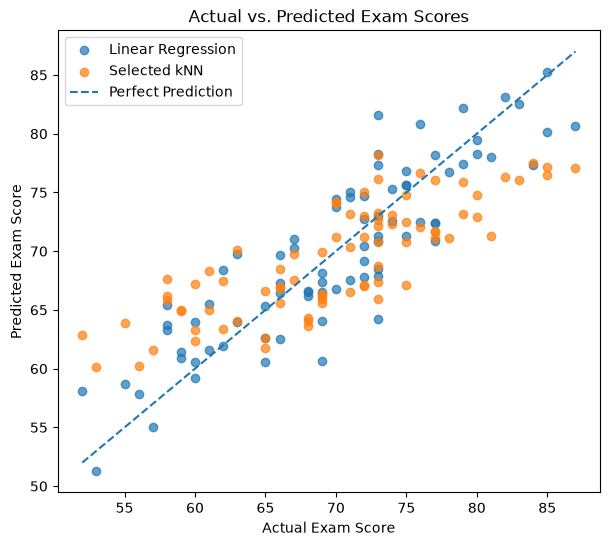

In [31]:
from sklearn.model_selection import KFold, cross_val_predict
import matplotlib.pyplot as plt

prediction_cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=407
)

final_knn = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsRegressor(
        n_neighbors=best_k,
        weights="distance"
    )),
])

lr_predictions = cross_val_predict(linear_model, X, y, cv=prediction_cv)
knn_predictions = cross_val_predict(final_knn, X, y, cv=prediction_cv)

plt.figure(figsize=(7, 6))
plt.scatter(y, lr_predictions, alpha=0.7, label="Linear Regression")
plt.scatter(y, knn_predictions, alpha=0.7, label="Selected kNN")
plt.plot(
    [y.min(), y.max()],
    [y.min(), y.max()],
    linestyle="--",
    label="Perfect Prediction"
)
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs. Predicted Exam Scores")
plt.legend()
plt.show()

The predicted-versus-actual plot shows how closely each model's predictions track the actual exam scores. The dashed line represent what perfect predictions would look like. Points scattered further from it represent larger errors. Linear Regression's points cluster more tightly around the line, reflecting its lower **RMSE** and higher **R².**

In [32]:
final_knn_results = cross_validate(final_knn, X, y, cv=cv, scoring=scoring)

final_comparison = pd.DataFrame({
    "Model": ["Linear Regression", f"kNN k={best_k} distance"],
    "MAE Mean": [
        -results_linear["test_MAE"].mean(),
        -final_knn_results["test_MAE"].mean()
    ],
    "MAE SD": [
        results_linear["test_MAE"].std(),
        final_knn_results["test_MAE"].std()
    ],
    "RMSE Mean": [
        -results_linear["test_RMSE"].mean(),
        -final_knn_results["test_RMSE"].mean()
    ],
    "RMSE SD": [
        results_linear["test_RMSE"].std(),
        final_knn_results["test_RMSE"].std()
    ],
    "R2 Mean": [
        results_linear["test_R2"].mean(),
        final_knn_results["test_R2"].mean()
    ],
    "R2 SD": [
        results_linear["test_R2"].std(),
        final_knn_results["test_R2"].std()
    ]
})

final_comparison.round(3)

,Model,MAE Mean,MAE SD,RMSE Mean,RMSE SD,R2 Mean,R2 SD
0,Linear Regression,3.08,0.46,3.77,0.51,0.75,0.07
1,kNN k=9 distance,4.24,0.52,5.01,0.55,0.57,0.07


Linear Regression had the lower **RMSE** and higher **R²,** so it gives better predictions for this baseline dataset. The selected kNN model (`k = 9`, distance weighting) narrows the gap compared to `k = 5` unscaled, but linear regression remains the stronger model for this clean baseline dataset.

### Final Interpretation

The best kNN model used **k = 9** with **distance weighting**. Distance weighting performed slightly better than uniform weighting.

However, **linear regression performed better overall**. Linear regression had a lower **RMSE** of about 3.77, while kNN had an **RMSE** of about 5.02. Linear Regression also had a higher **R²** of about 0.75, compared with about 0.57 for kNN. This means linear regression was better at predicting exam scores for this dataset.

For kNN, performance improved as `k` increased from 1 to 9. At `k = 15`, performance declined slightly. This shows that using too few or too many neighbors can affect how well the model performs.

Our dataset was the clean baseline, so there were no added outliers, categorical variables, or other abnormalities in the data.

One limitation is that the dataset consisted of only **80 records,** all of which represented synthetic students. Results may differ with real student data or a larger dataset.

The results show that `Hours_Studied`, `Attendance_Percent`, `Sleep_Hours`, and `Assignments_Completed` all contribute to the target `Exam_Score` in this dataset. However, this does not mean that changing one of these things will directly cause a student's exam score to change.